# Gaussian Process Regression - Artificial Dataset

This notebook is used to
1. Generate some artificial time-series data
1. Train a GP model on that data
1. Analyse the perform of such a model, with plots and so-on

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from numpy import ndarray

sns.set_theme(style="white", context="notebook")

RANDOM_SEED = 0
rng = np.random.default_rng(RANDOM_SEED)

## Generating artificial data

We want to generate some artificial data that mimics the general behaviour we'd expect in a time-series. For this simple example, let's just have three main components:
- A linear trend
- A periodic component
- Some Gaussian noise

In [2]:
def generate_dummy_data(
        start: float, end: float, n: int,
        slope: float = 2.0, amp: float = 3.0, freq: float = 2 * np.pi, noise_var: float = 1.0,
        add_noise: bool = True
    ) -> tuple[ndarray, ndarray]:
    """Generate some dummy time-series data. This fake time-series contains just the basic behaviour
    we'd like to model with the GP regressor: linear, seasonal, and noise components. Returns a 
    tuple containing (i) the `n` time indices over the domain `[start, end]` and (ii) the `n`
    observations given by the simple formula:
    `f(t) = slope * t + amp * sin(freq * t) + eps`
    where `eps` are iid `N(0, noise_var)`.

    Args:
        start (float): Initial time bound.
        end (float): End time bound.
        n (int): Number of points.
        slope (float, optional): Slope of the linear component. Defaults to 2.0.
        amp (float, optional): Amplitude of the seasonal component. Defaults to 10.0.
        freq (float, optional): Frequency of the seasonal component. Defaults to 2*np.pi.
        noise_var (float, optional): Variance of the Gaussian noise added to each observatin. Defaults to 1.0.

    Returns:
        tuple[ndarray, ndarray]: (time_indices, observations)
    """
    X = np.linspace(start, end, n)

    # Linear component
    trend = slope * X

    # Periodic component
    seasonality = amp * np.sin(freq * X)

    # Add some Gaussian noise
    if add_noise:
        noise = rng.normal(loc=0.0, scale=np.sqrt(noise_var), size=n)
    else:
        noise = 0
    
    Y = trend + seasonality + noise
    return (X, Y)


In [3]:
START, END = 0, 7
N_POINTS = 200

X, y = generate_dummy_data(START, END, N_POINTS)
y_mean = y.mean()

In [4]:
X_true, y_true = generate_dummy_data(START, END, 1000, add_noise=False)

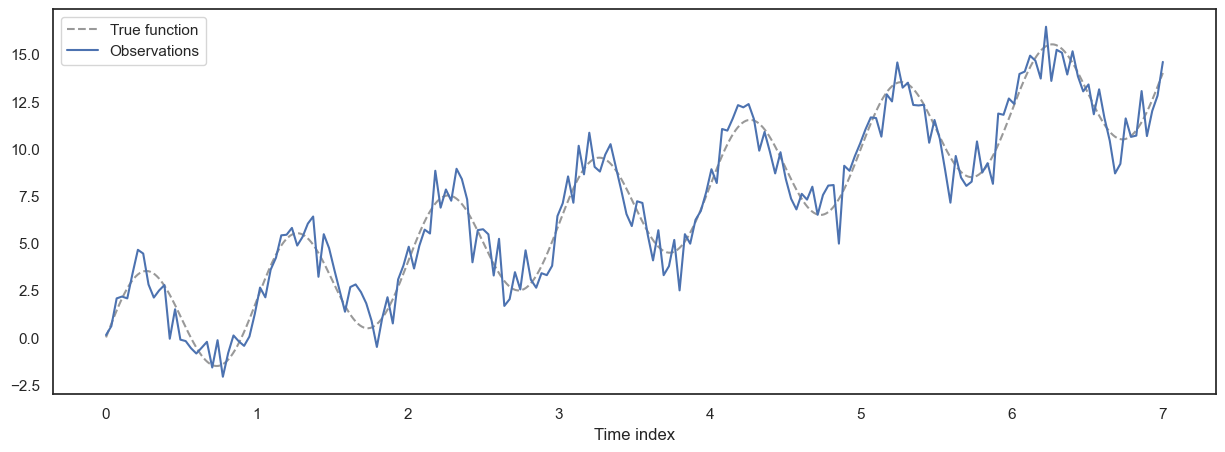

In [5]:
# TODO add axes labels
# TODO move markers to front
# TODO add equation to plot
plt.figure(figsize=(15,5))
sns.lineplot(x=X_true, y=y_true, c="black", alpha=0.4, linestyle="--", label="True function")

# for _ in range(5):
#     dum_x, dum_y = generate_dummy_data(START, END, N_POINTS)
#     sns.lineplot(x=dum_x, y=dum_y)

sns.lineplot(x=X, y=y, label="Observations")

plt.xlabel("Time index")
plt.show()

In [6]:
y -= y_mean # Mean centering for GP

## Fitting a GP

The artificial data looks about how we'd expect. Next, we want to fit a GP to this dummy data. To do this, we will create an additive kernel with a component for each part of the dummy data:
- Trend -> RBF (or linear) -> $l$ (or $c^2$)
- Seasonal -> periodic (or with decay) -> $l$ and $p$ (or with $l_2$)
- Noise -> white noise -> $\sigma^2$

and each kernel can also have a scale parameter $\zeta^2$ out the front. Hence the summed kernel will be
$$k(x,x') = k_{RQ} + k_{ESS} + k_{WN}$$

In [7]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import *

kernel_lin = ConstantKernel(1.0) * DotProduct(1.0)
# kernel_lin = ConstantKernel(1.0) * RBF(1.0)
kernel_per = ConstantKernel(1.0) * ExpSineSquared(length_scale=1.0, periodicity=1, periodicity_bounds="fixed")
# kernel_per = ConstantKernel(1.0) * ExpSineSquared(length_scale=1.0, periodicity=1, periodicity_bounds="fixed") * RBF(1.0)
kernel_noi = WhiteKernel(1.0, noise_level_bounds=(1e-5, 1e1))
kernel = kernel_lin + kernel_per + kernel_noi

In [8]:
X = X.reshape(-1, 1)
y = y.reshape(-1, 1)

n_restarts = 3
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=n_restarts, random_state=RANDOM_SEED)

In [9]:
gp.fit(X, y)

GaussianProcessRegressor(kernel=1**2 * DotProduct(sigma_0=1) + 1**2 * ExpSineSquared(length_scale=1, periodicity=1) + WhiteKernel(noise_level=1),
                         n_restarts_optimizer=3, random_state=0)

In [10]:
gp.kernel_

1.97**2 * DotProduct(sigma_0=0.0101) + 10.1**2 * ExpSineSquared(length_scale=5.93, periodicity=1) + WhiteKernel(noise_level=0.919)

## Analysing model fit

So the GP is now fit. Some fiddling might've been necessary to get a well-behaved kernel optimisation, and will depend on what parameters we set for the dummy data (if we happen to change that). With this done, we can move onto the crux which is visualising and explaining what magic the model is doing.

In [11]:
def visualise_gpr(
        gp: GaussianProcessRegressor, data: list = None, true_fn: list = None,
        start: float = None, end: float = None, n: float = 100, figsize: tuple = (12, 6)):
    """Visualise a fitted GP model. Should work so that you can optionally pass the observations or
    the true function value, but I'd recommend both to show the full picture. If you don't pass the
    time bounds `(start, end)`, then it'll try finding the bounds of the index in `data[0]`.

    Args:
        gp (GaussianProcessRegressor): The fitted GP regressor.
        data (list, optional): Observations `(t, f(t))`. Defaults to None.
        true_fn (list, optional): True function values `(t, f(t))`. Defaults to None.
        start (float, optional): Left time bound for plotting. Defaults to None.
        end (float, optional): Right time bound for plotting. Defaults to None.
        n (float, optional): Number of points. Defaults to 100.
    """
    bounds_bool = start is not None and end is not None
    assert bounds_bool or (data)
    if not bounds_bool:
        start = data[0].min()
        end = data[0].max()
    y_mean = data[1].mean() if data else 0.0

    plt.figure(figsize=figsize)

    # GP preds
    X_plot = np.linspace(start, end, n).reshape(-1, 1)
    y_pred_centered, sigma_centered = gp.predict(X_plot, return_std=True)
    X_plot = X_plot.ravel()
    y_pred = y_pred_centered.ravel() + y_mean
    sigma = sigma_centered.ravel()

    sns.lineplot(x=X_plot, y=y_pred, lw=2, c="orange", label="Posterior mean")
    plt.fill_between(
        X_plot, y_pred - 2 * sigma, y_pred + 2 * sigma, 
        color="orange", alpha=0.25, label="\u00B1 2 x std"
    )

    # Data
    if data:
        sns.scatterplot(x=data[0], y=data[1], s=10, lw=0, label="Observations", zorder=2)

    # True fn
    if true_fn:
        sns.lineplot(x=true_fn[0], y=true_fn[1], label="True function", linestyle="--")

    # Extra things
    plt.show()


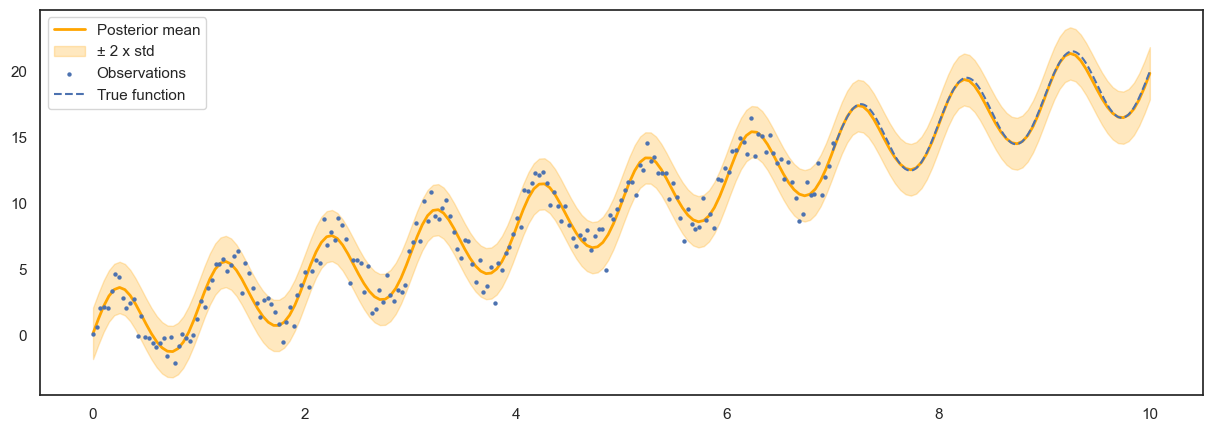

In [12]:
FORECAST = 3

data = [X.ravel(), y.ravel() + y_mean]
# true_fn = [X_true, y_true]
true_fn = generate_dummy_data(END, END + FORECAST, 1000, add_noise=False)
# true_fn = None

visualise_gpr(gp, data, true_fn, START, END + FORECAST, N_POINTS, (15, 5))

We might also want to talk about metrics. The coefficient of determination is readily available for the fitted model. We may need to do some more work to get cross validated errors.

In [13]:
gp.score(X, y)

0.9538650896115818

In [14]:
gp.log_marginal_likelihood_value_

np.float64(-291.2643079123678)

## Visualising inidividual kernel components

With the main GP fitted and plotted, we can finish the interpretation by plotting the individual kernels to understand what the learned hyperparameters are doing.

In [15]:
gp.kernel_

1.97**2 * DotProduct(sigma_0=0.0101) + 10.1**2 * ExpSineSquared(length_scale=5.93, periodicity=1) + WhiteKernel(noise_level=0.919)

1.97**2 * DotProduct(sigma_0=0.0101)


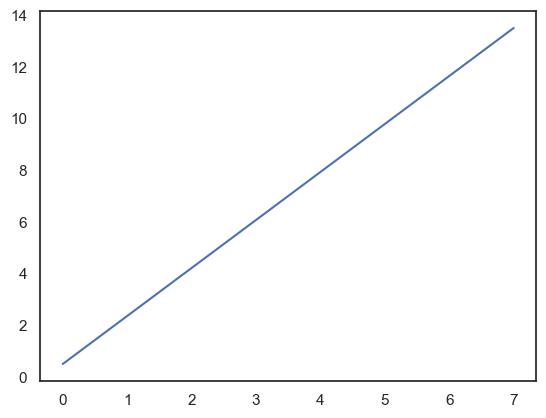

In [16]:
ker = gp.kernel_.k1.k1
print(ker)

gp_trend = GaussianProcessRegressor(kernel=ker, alpha=1e-9, optimizer=None)
gp_trend.fit(X, y)

x_k1 = np.linspace(START, END, 1000)
y_k1 = gp_trend.predict(x_k1.reshape(-1, 1)) + y_mean

sns.lineplot(x=x_k1, y=y_k1)
plt.show()

10.1**2 * ExpSineSquared(length_scale=5.93, periodicity=1)


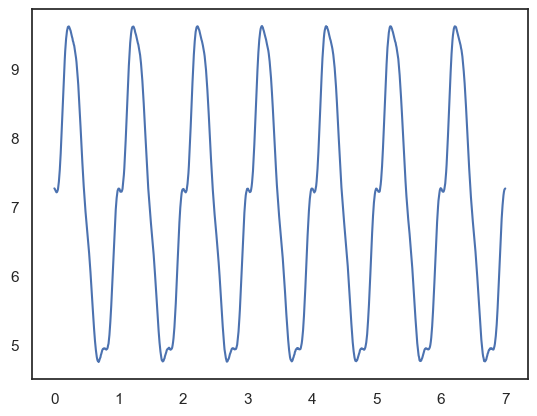

In [17]:
ker = gp.kernel_.k1.k2
print(ker)

gp_trend = GaussianProcessRegressor(kernel=ker, alpha=1e-9, optimizer=None)
gp_trend.fit(X, y)

x_k1 = np.linspace(START, END, 1000)
y_k1 = gp_trend.predict(x_k1.reshape(-1, 1)) + y_mean

sns.lineplot(x=x_k1, y=y_k1)
plt.show()